# Heart Disease Prediction: EDA, Model Building and Evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Integration

The dataset provided for this project is split into two separate files, one containing the patient features (medical test results, age, etc) and another containing the target variable ('heart_disease_present').

To prepare our data for EDA, we need to combine these into a single, unified dataset. We will use the 'pateint_id' column as our primary key to perform an inner join, ensuring we only keep records that have both features and a known target.

In [13]:
# Load features and target datasets
features_df = pd.read_csv('../data/values.csv')
target_df = pd.read_csv('../data/labels.csv')

# Merge datasets on patient_id
# Using an inner join to ensure data integrity (no missing targets)
df = pd.merge(features_df, target_df, on='patient_id', how='inner')

# Verify the merge and inspect the first 5 rows
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


**Observation:** The merge was successful. We now have a unified dataset with our features and our target variable.

## Data Inspection
In this step we are going to inspect the data and try to answer the following questions,

1. What are the different data types we are working with?
2. Are there any Null values?
3. Are there any inconsistencies or impossible values?
4. What does the statistical distribution of the numerical features look like?
   

In [10]:
# Get summary of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    str    
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    str    
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                           

In [11]:
# Get statistical distribution of the numerical features
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


**Observation:** From the summary and the statistical distribution of the data, we can observe that,

1. There are 13 numerical columns and 2 categorical columns
2. There are no Null values
3. There are no inconsistencies or impossible values

## Target variable analysis
We need to analyse the target variable and see if the data is well-balanced or imbalanced. 

This is important because if the distribution of the target variable is imbalanced the model will become dumb, for example 90% of the patients do not have disease and only 10% have disease then the model will learn this and predict most of the times that the patient does not have a disease even if they do have it. On paper it will show that the model has 90% accuracy but it fails to fulfill the purpose of correctly predicting as to which person has the disease.

heart_disease_present
0    100
1     80
Name: count, dtype: int64

Percentage Distribution:
 heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64


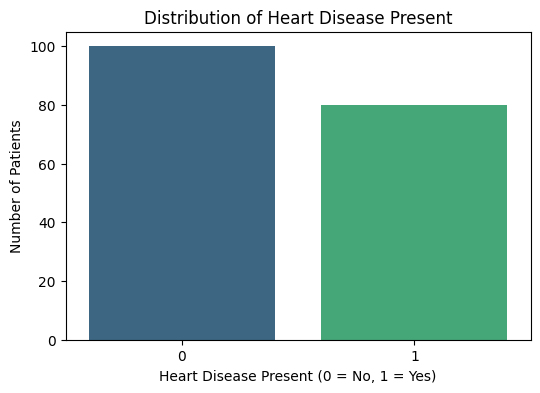

In [21]:
# Calculate the exact counts of each class
target_counts = df['heart_disease_present'].value_counts()
print(target_counts)

# Calculate the percentage distribution
target_percentages = df['heart_disease_present'].value_counts(normalize=True)*100
print("\nPercentage Distribution:\n", target_percentages)

# Visualize the distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='heart_disease_present', hue='heart_disease_present', legend=False, palette='viridis')
plt.title('Distribution of Heart Disease Present')
plt.xlabel('Heart Disease Present (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

**Observation:** Luckily the target vairable in this dataset has a 55/45 split which means that it does not have an imbalanced class distribution. This indicates a well-balanced dataset, meaning we will not need to apply class imbalance handling techniques prior to modeling.

## Bivariate Analysis: Numerical Features vs Target
In this part, we are going to compare a numerical feature to the target variable and see if there is any relation between them.

From intuition we know that 'Age' and 'Heart rate' might cause a heart attack so let's see if these features have any relation with the target variable.

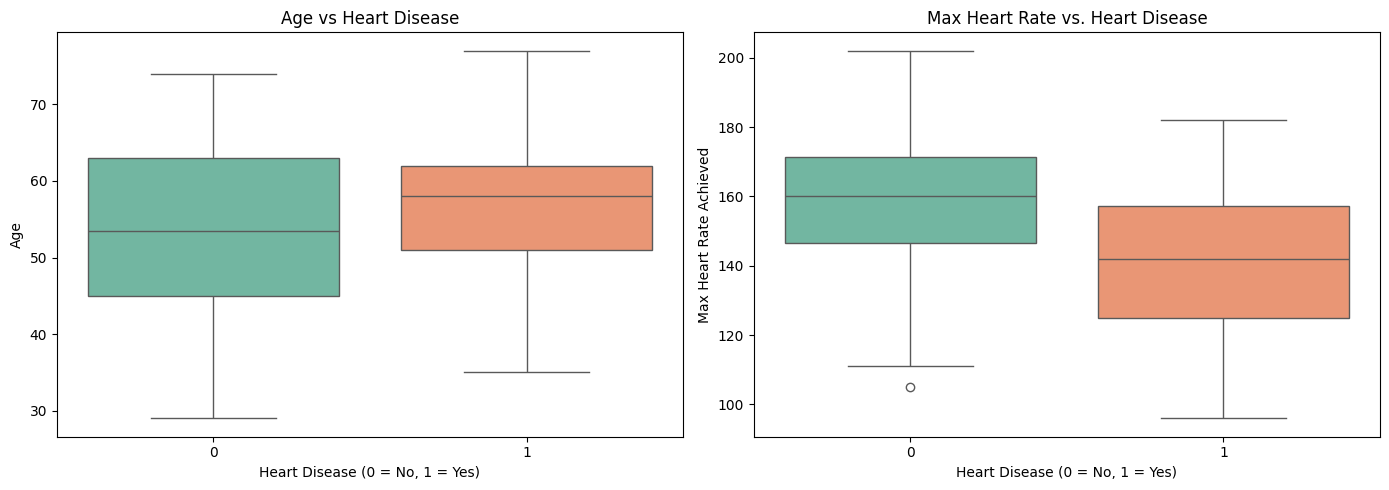

In [23]:
# Creaate a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Plot 1: Age vs Heart Disease
sns.boxplot(data=df, x='heart_disease_present', y='age', hue ='heart_disease_present', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Age vs Heart Disease')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Age')

# Plot 2: Max Heart Rate vs Heart Disease
sns.boxplot(data=df, x='heart_disease_present', y='max_heart_rate_achieved', hue='heart_disease_present', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Max Heart Rate vs. Heart Disease')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Max Heart Rate Achieved')

plt.tight_layout()
plt.show()

**Observation:**

1. **Age:** Patients with heart disease tend to be older (higher median age) compared to those without.

2. **Max Heart Rate:** Patients with heart disease tend to achieve a significantly lower maximum heart rate during exercise.
Both features show a clear separation between classes, indicating they will be strong predictors for our machine learning model.

## Bivariate Analyis: Categorical Features vs Target

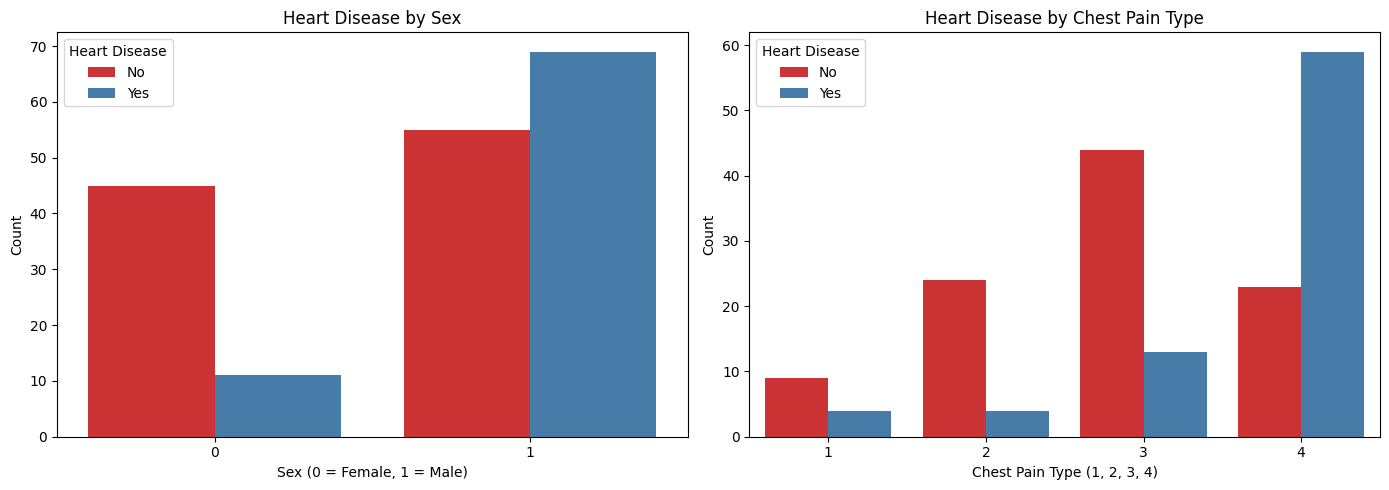

In [24]:
# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sex vs Heart Disease
sns.countplot(data=df, x='sex', hue='heart_disease_present', ax=axes[0], palette='Set1')
axes[0].set_title('Heart Disease by Sex')
axes[0].set_xlabel('Sex (0 = Female, 1 = Male)')
axes[0].set_ylabel('Count')
axes[0].legend(title='Heart Disease', labels=['No', 'Yes'])

# Plot 2: Chest Pain Type vs Heart Disease
sns.countplot(data=df, x='chest_pain_type', hue='heart_disease_present', ax=axes[1], palette='Set1')
axes[1].set_title('Heart Disease by Chest Pain Type')
axes[1].set_xlabel('Chest Pain Type (1, 2, 3, 4)')
axes[1].set_ylabel('Count')
axes[1].legend(title='Heart Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

**Observation:**

1. Sex: Males show a higher proportion of heart disease compared to females in this dataset.
2. Chest Pain Type: Patients presenting with chest pain type 4 have a drastically higher rate of heart disease. This feature shows massive predictive potential.

## Correlation Heatmap

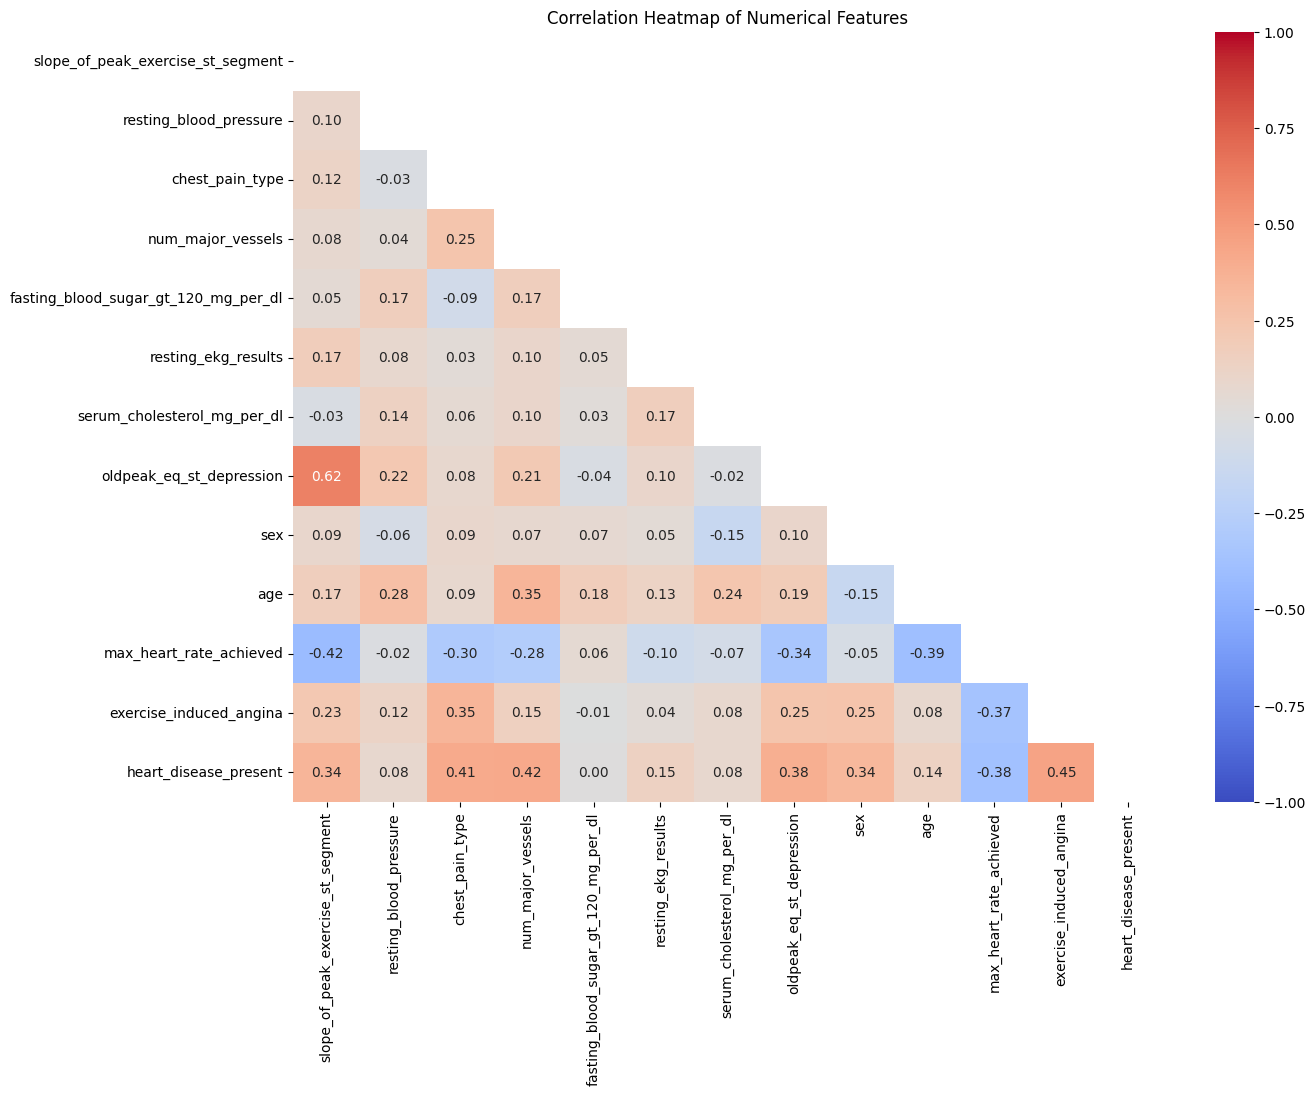

In [25]:
# Select only numerical columns for correlation math
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create a mask to hide the top right triangle (makes it look much cleaner and professional!)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()